In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Wczytanie danych i poprawne parsowanie czasu
# Używamy pd.to_datetime, aby poprawnie obliczyć dt w sekundach
normal = pd.read_excel("Przebieg normalny.xlsx")
disturbed = pd.read_excel("Przebieg zaburzony.xlsx")


In [ ]:


normal['Time'] = pd.to_datetime(normal['Time'])
disturbed['Time'] = pd.to_datetime(disturbed['Time'])

# Krok czasowy dt w sekundach
dt = (normal["Time"].iloc[1] - normal["Time"].iloc[0]).total_seconds()

# Sygnały dla przebiegu normalnego
y_n = normal["y (T)"].values
u_n = normal["u (Pg)"].values
z_n = normal["z (Tz)"].values


In [4]:
# --- CZĘŚĆ (i) Zad. 1 & 2: Identyfikacja ---
# Równanie dyskretne: y[n+1] = y[n] + (dt/c)*u[n] + (d*dt/c)*(z[n] - y[n])
# Niech a = dt/c oraz b = d*dt/c
# Wtedy: y[n+1] - y[n] = a*u[n] + b*(z[n] - y[n])

Y = y_n[1:] - y_n[:-1]
Phi = np.column_stack([u_n[:-1], z_n[:-1] - y_n[:-1]])

# MNK (Metoda Najmniejszych Kwadratów)
theta, _, _, _ = np.linalg.lstsq(Phi, Y, rcond=None)
a_est, b_est = theta


In [5]:

# Wyznaczenie parametrów fizycznych c i d
c_val = dt / a_est
d_val = b_est / a_est # bo b = d*a

print(f"Zidentyfikowane parametry: c = {c_val:.2f}, d = {d_val:.4f}")

Zidentyfikowane parametry: c = 2537.89, d = 1.0551


In [6]:


# --- CZĘŚĆ (i) Zad. 3: Predykcja z horyzontem h ---
def predict_h_steps(y_real, u_real, z_real, a, b, h):
    """
    Wyznacza predykcję y_hat w chwili n na podstawie y_real z chwili n-h
    i wykonuje h kroków iteracji modelu.
    """
    N = len(y_real)
    y_hat = np.zeros(N)
    y_hat[:h] = y_real[:h] # Początek nie ma wystarczającej historii
    
    for n in range(h, N):
        # Startujemy z rzeczywistej wartości sprzed h kroków
        val = y_real[n-h]
        # Wykonujemy h kroków symulacji modelem
        for i in range(h):
            idx = n - h + i
            val = val + a * u_real[idx] + b * (z_real[idx] - val)
        y_hat[n] = val
    return y_hat

horizons = [1, 5, 20] # Przykładowe horyzonty (100 to może być za dużo dla stabilności)
predictions = {h: predict_h_steps(y_n, u_n, z_n, a_est, b_est, h) for h in horizons}


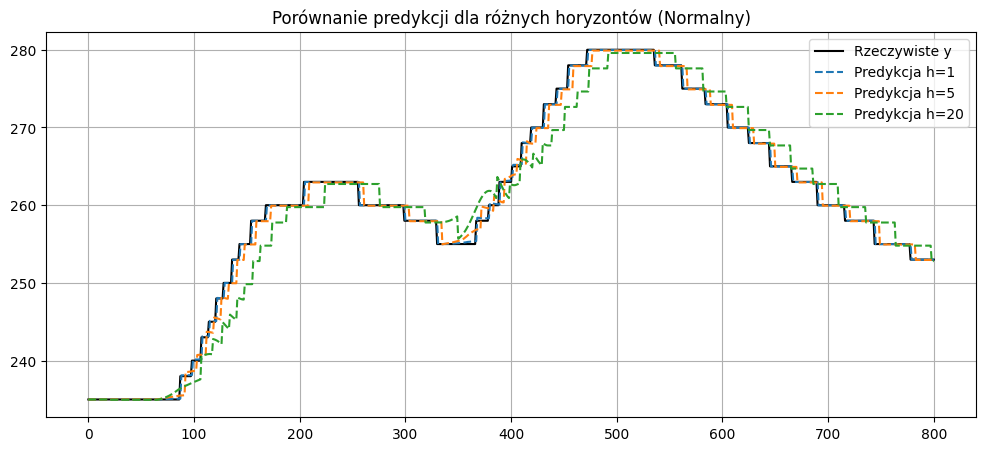

In [7]:
# --- Wykresy Część (i) Zad. 4 ---
plt.figure(figsize=(12, 5))
plt.plot(y_n, 'k', label="Rzeczywiste y", linewidth=1.5)
for h in horizons:
    plt.plot(predictions[h], '--', label=f"Predykcja h={h}")
plt.title("Porównanie predykcji dla różnych horyzontów (Normalny)")
plt.legend()
plt.grid()
plt.show()

In [8]:
# --- CZĘŚĆ (ii) Zad. 1-5: Detekcja anomalii ---
y_dist = disturbed["y (T)"].values
u_dist = disturbed["u (Pg)"].values
z_dist = disturbed["z (Tz)"].values

# Predykcja na danych zaburzonych
pred_dist = {h: predict_h_steps(y_dist, u_dist, z_dist, a_est, b_est, h) for h in horizons}
res_dist = {h: y_dist - pred_dist[h] for h in horizons}
res_norm = {h: y_n - predictions[h] for h in horizons}


In [10]:

# Zad. 5: Wyznaczenie progu sigma
for h in horizons:
    sigma = np.std(res_norm[h])
    threshold = 3 * sigma
    print(f"Horyzont h={h}: sigma={sigma:.3f}, Próg (3*sigma)={threshold:.3f}")


Horyzont h=1: sigma=0.531, Próg (3*sigma)=1.592
Horyzont h=5: sigma=1.139, Próg (3*sigma)=3.416
Horyzont h=20: sigma=2.562, Próg (3*sigma)=7.686


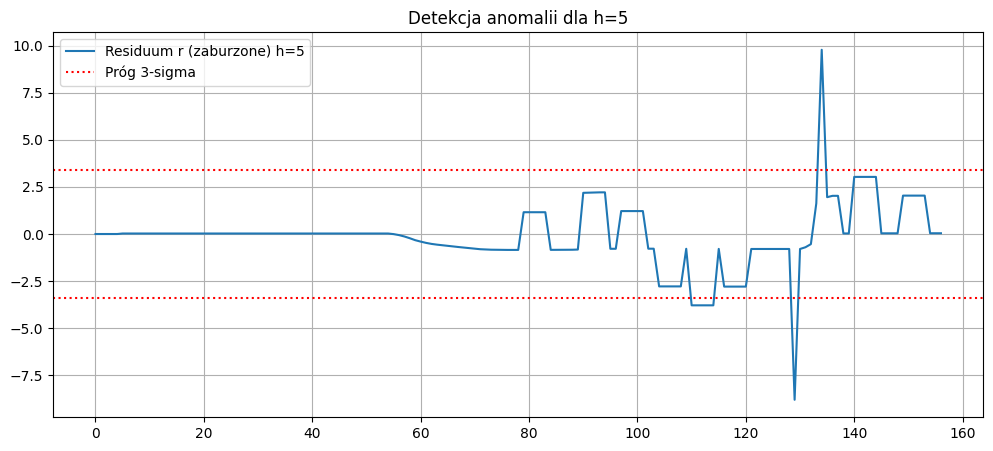

In [11]:

# Wykres residuów dla danych zaburzonych
plt.figure(figsize=(12, 5))
h_to_plot = horizons[1] # Wybieramy jeden horyzont do analizy
plt.plot(res_dist[h_to_plot], label=f"Residuum r (zaburzone) h={h_to_plot}")
plt.axhline(y=3*np.std(res_norm[h_to_plot]), color='r', linestyle=':', label="Próg 3-sigma")
plt.axhline(y=-3*np.std(res_norm[h_to_plot]), color='r', linestyle=':')
plt.title(f"Detekcja anomalii dla h={h_to_plot}")
plt.legend()
plt.grid()
plt.show()